# 08. Integrated Personalization Framework

This notebook integrates the cart-to-purchase prediction model, the behavior-based item-to-item recommender, and the probability-based action policy into one explainable e-commerce personalization framework.

In [1]:
# Purpose: Load the trained purchase model, recommendation artifact, and temporal cart data for integrated personalization examples.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

current_path = Path.cwd().resolve()

project_root = next(
    (
        candidate
        for candidate in [current_path, *current_path.parents]
        if (candidate / "data").exists()
    ),
    current_path
)

processed_data_dir = project_root / "data" / "processed"
figures_dir = project_root / "outputs" / "figures"
tables_dir = project_root / "outputs" / "tables"
models_dir = project_root / "outputs" / "models"

modeling_data_path = processed_data_dir / "cart_purchase_modeling_dataset.csv"
model_path = models_dir / "final_catboost_cart_purchase_model.cbm"
recommendations_path = (
    processed_data_dir / "retailrocket_item_to_item_recommendations.csv"
)

integration_df = pd.read_csv(
    modeling_data_path,
    parse_dates=["cart_time"]
)

item_recommendations_df = pd.read_csv(recommendations_path)

integration_model = CatBoostClassifier()
integration_model.load_model(model_path)

target_column = "purchased_within_14_days"

integration_feature_columns = [
    column
    for column in integration_df.columns
    if column not in ["visitorid", "itemid", "cart_time", target_column]
]

integration_cutoff = integration_df["cart_time"].quantile(0.80)

integration_test_df = (
    integration_df
    .loc[integration_df["cart_time"] > integration_cutoff]
    .copy()
    .reset_index(drop=True)
)

integration_test_df["predicted_purchase_probability"] = (
    integration_model.predict_proba(
        integration_test_df[integration_feature_columns]
    )[:, 1]
)

print(f"Project root: {project_root}")
print(f"Temporal cart records available for integration: {len(integration_test_df):,}")
print(
    "Cart-item sources with recommendations: "
    f"{item_recommendations_df['source_item_id'].nunique():,}"
)
print(f"Loaded model: {model_path.name}")
print(f"Loaded recommendation artifact: {recommendations_path.name}")

Project root: F:\ecommerce-recommender-xai
Temporal cart records available for integration: 11,277
Cart-item sources with recommendations: 12,033
Loaded model: final_catboost_cart_purchase_model.cbm
Loaded recommendation artifact: retailrocket_item_to_item_recommendations.csv


In [2]:
# Purpose: Create integrated cart-level routing rules that combine purchase probability, recommended action, and related-item suggestions.

TOP_RELATED_ITEMS = 3

related_item_lookup = (
    item_recommendations_df
    .sort_values(
        [
            "source_item_id",
            "cosine_association_score",
            "cooccurrence_count"
        ],
        ascending=[True, False, False]
    )
    .groupby("source_item_id")["recommended_item_id"]
    .agg(lambda item_ids: list(item_ids.head(TOP_RELATED_ITEMS)))
    .to_dict()
)

integration_test_df["probability_segment"] = pd.cut(
    integration_test_df["predicted_purchase_probability"],
    bins=[-0.001, 0.10, 0.25, 0.40, 0.70, 1.00],
    labels=[
        "Very low probability",
        "Low probability",
        "Moderate probability",
        "High probability",
        "Very high probability"
    ],
    include_lowest=True,
    right=False
)

integration_test_df["recommended_action"] = np.select(
    [
        integration_test_df["predicted_purchase_probability"] < 0.10,
        integration_test_df["predicted_purchase_probability"] < 0.25,
        integration_test_df["predicted_purchase_probability"] < 0.40,
        integration_test_df["predicted_purchase_probability"] < 0.70
    ],
    [
        "No immediate push; show relevant alternatives later.",
        "Use a delayed reminder or low-cost related-item recommendation.",
        "Show reassurance and related items; test a modest incentive in an experiment.",
        "Send a timely reminder and reduce checkout friction."
    ],
    default="Prioritize seamless checkout; do not give a default discount."
)

integration_test_df["related_item_ids"] = (
    integration_test_df["itemid"]
    .map(related_item_lookup)
)

integration_test_df["has_related_item_recommendations"] = (
    integration_test_df["related_item_ids"].notna()
)

integration_test_df["top_related_item_ids"] = (
    integration_test_df["related_item_ids"]
    .apply(
        lambda item_ids: ", ".join(map(str, item_ids))
        if isinstance(item_ids, list)
        else "No behavior-based recommendation available"
    )
)

integration_routing_columns = [
    "visitorid",
    "itemid",
    "cart_time",
    "predicted_purchase_probability",
    "probability_segment",
    "recommended_action",
    "has_related_item_recommendations",
    "top_related_item_ids",
    target_column
]

integrated_routing_df = integration_test_df[
    integration_routing_columns
].copy()

integration_routing_path = (
    tables_dir / "14_integrated_personalization_routing.csv"
)
integrated_routing_df.to_csv(integration_routing_path, index=False)

integration_coverage_summary = pd.DataFrame({
    "metric": [
        "Temporal cart records",
        "Carts with related-item recommendations",
        "Related-item recommendation coverage",
        "Average predicted purchase probability"
    ],
    "value": [
        len(integrated_routing_df),
        int(integrated_routing_df["has_related_item_recommendations"].sum()),
        integrated_routing_df["has_related_item_recommendations"].mean(),
        integrated_routing_df["predicted_purchase_probability"].mean()
    ]
})

display(integration_coverage_summary)

display(
    integrated_routing_df
    .sort_values("predicted_purchase_probability", ascending=False)
    .head(5)
)

print(f"Saved integrated routing table to: {integration_routing_path}")

,metric,value
0,Temporal cart records,11277.000000
1,Carts with related-item recommendations,6489.000000
2,Related-item recommendation coverage,0.575419
3,Average predicted purchase probability,0.296817


,visitorid,itemid,cart_time,predicted_purchase_probability,probability_segment,recommended_action,has_related_item_recommendations,top_related_item_ids,purchased_within_14_days
9557,530559,175356,2015-08-30 22:47:55.166,0.899061,Very high probability,Prioritize seamless checkout; do not give a de...,True,"391289, 16813, 280375",0
3852,1150086,196540,2015-08-17 21:49:20.993,0.883205,Very high probability,Prioritize seamless checkout; do not give a de...,False,No behavior-based recommendation available,1
999,530559,432152,2015-08-10 21:49:23.674,0.882919,Very high probability,Prioritize seamless checkout; do not give a de...,True,"367664, 89262, 257040",1
10203,152963,29863,2015-09-01 17:09:06.718,0.881963,Very high probability,Prioritize seamless checkout; do not give a de...,True,"359040, 89775, 102471",1
10154,152963,340375,2015-09-01 15:11:09.633,0.880678,Very high probability,Prioritize seamless checkout; do not give a de...,True,"80435, 337327, 227318",0


Saved integrated routing table to: F:\ecommerce-recommender-xai\outputs\tables\14_integrated_personalization_routing.csv


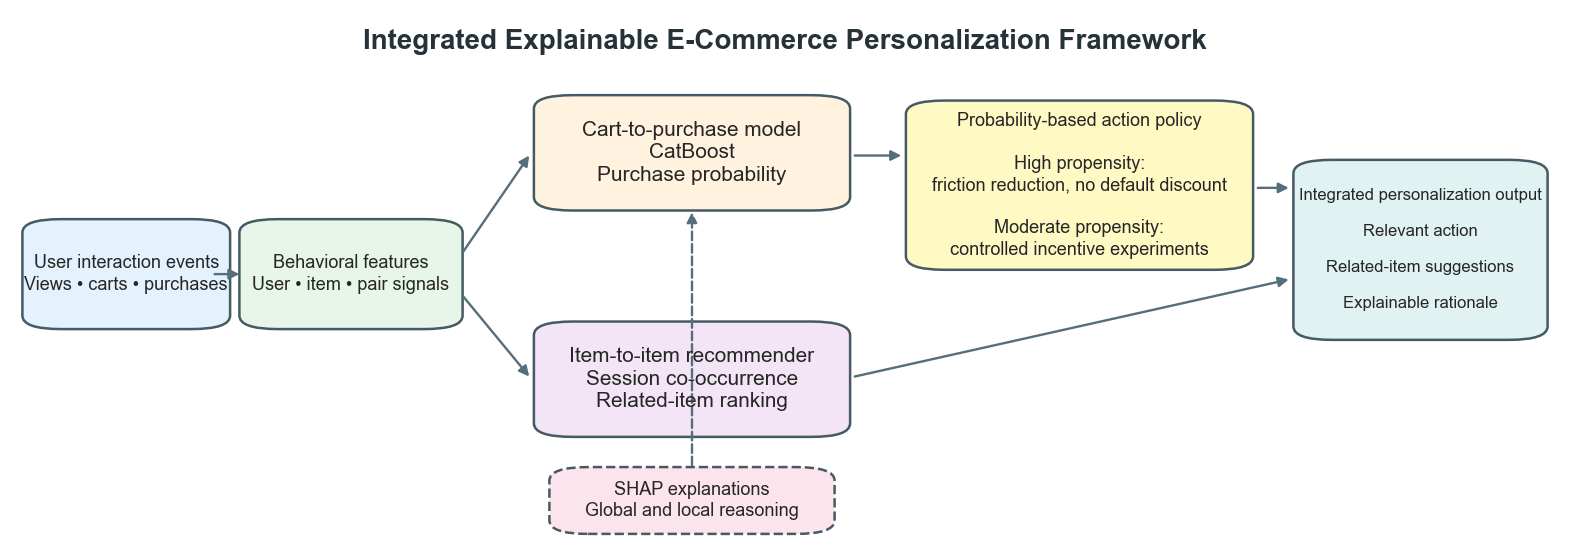

Saved integrated framework figure to: F:\ecommerce-recommender-xai\outputs\figures\17_integrated_personalization_framework.png


In [29]:
# Purpose: Create and save a clear horizontal framework diagram with larger text and arrows outside all blocks.

from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

fig, ax = plt.subplots(figsize=(20, 7))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

def add_box(
    x, y, width, height, text, color,
    edge_color="#455A64", dashed=False, fontsize=10
):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.012,rounding_size=0.025",
        facecolor=color,
        edgecolor=edge_color,
        linewidth=1.8,
        linestyle="--" if dashed else "-"
    )
    ax.add_patch(box)

    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        linespacing=1.25
    )

def add_arrow(start_x, start_y, end_x, end_y, dashed=False):
    arrow = FancyArrowPatch(
        (start_x, start_y),
        (end_x, end_y),
        arrowstyle="-|>",
        mutation_scale=15,
        linewidth=1.7,
        color="#546E7A",
        linestyle="--" if dashed else "-",
        shrinkA=0,
        shrinkB=0
    )
    ax.add_patch(arrow)

# Input and feature layer
add_box(
    0.02, 0.42, 0.11, 0.18,
    "User interaction events\nViews • carts • purchases",
    "#E3F2FD",
    fontsize=13
)

add_box(
    0.16, 0.42, 0.12, 0.18,
    "Behavioral features\nUser • item • pair signals",
    "#E8F5E9",
    fontsize=13
)

# Parallel components
add_box(
    0.35, 0.64, 0.18, 0.19,
    "Cart-to-purchase model\nCatBoost\nPurchase probability",
    "#FFF3E0",
    fontsize=15
)

add_box(
    0.35, 0.22, 0.18, 0.19,
    "Item-to-item recommender\nSession co-occurrence\nRelated-item ranking",
    "#F3E5F5",
    fontsize=15
)

add_box(
    0.36, 0.04, 0.16, 0.10,
    "SHAP explanations\nGlobal and local reasoning",
    "#FCE4EC",
    dashed=True,
    fontsize=13
)

# Decision and output layer
add_box(
    0.59, 0.53, 0.20, 0.29,
    "Probability-based action policy\n\nHigh propensity:\nfriction reduction, no default discount\n\nModerate propensity:\ncontrolled incentive experiments",
    "#FFF9C4",
    fontsize=13
)

add_box(
    0.84, 0.40, 0.14, 0.31,
    "Integrated personalization output\n\nRelevant action\n\nRelated-item suggestions\n\nExplainable rationale",
    "#E0F2F1",
    fontsize=12
)

# Arrows placed fully in the whitespace between blocks
add_arrow(0.132, 0.51, 0.148, 0.51)
add_arrow(0.292, 0.55, 0.335, 0.73)
add_arrow(0.292, 0.47, 0.335, 0.32)
add_arrow(0.545, 0.73, 0.575, 0.73)
add_arrow(0.545, 0.32, 0.825, 0.50)
add_arrow(0.805, 0.67, 0.825, 0.67)
add_arrow(0.44, 0.155, 0.44, 0.625, dashed=True)

ax.text(
    0.5,
    0.94,
    "Integrated Explainable E-Commerce Personalization Framework",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold",
    color="#263238"
)

framework_figure_path = (
    figures_dir / "17_integrated_personalization_framework.png"
)

plt.savefig(framework_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved integrated framework figure to: {framework_figure_path}")

In [30]:
# Purpose: Summarize the combined prediction, action-routing, and recommendation coverage results by probability segment.

integrated_operational_summary = (
    integrated_routing_df
    .groupby("probability_segment", observed=False)
    .agg(
        cart_count=("visitorid", "size"),
        average_predicted_probability=(
            "predicted_purchase_probability",
            "mean"
        ),
        observed_purchase_rate=(target_column, "mean"),
        related_item_recommendation_coverage=(
            "has_related_item_recommendations",
            "mean"
        )
    )
    .reset_index()
)

integrated_operational_summary["average_predicted_probability"] = (
    integrated_operational_summary["average_predicted_probability"] * 100
).round(2)

integrated_operational_summary["observed_purchase_rate"] = (
    integrated_operational_summary["observed_purchase_rate"] * 100
).round(2)

integrated_operational_summary["related_item_recommendation_coverage"] = (
    integrated_operational_summary[
        "related_item_recommendation_coverage"
    ] * 100
).round(2)

integrated_operational_summary["action_policy"] = [
    "Show relevant alternatives later; avoid immediate repeated messaging.",
    "Use a delayed reminder or low-cost related-item recommendation.",
    "Show reassurance and related items; test incentives through A/B testing.",
    "Send a timely reminder and reduce checkout friction.",
    "Prioritize seamless checkout; avoid a default discount."
]

integrated_summary_path = (
    tables_dir / "15_integrated_framework_operational_summary.csv"
)
integrated_operational_summary.to_csv(
    integrated_summary_path,
    index=False
)

display(integrated_operational_summary)

print(f"Saved integrated operational summary to: {integrated_summary_path}")

,probability_segment,cart_count,average_predicted_probability,observed_purchase_rate,related_item_recommendation_coverage,action_policy
0,Very low probability,1090,8.03,5.96,67.61,Show relevant alternatives later; avoid immedi...
1,Low probability,4929,17.36,17.24,58.43,Use a delayed reminder or low-cost related-ite...
2,Moderate probability,2785,31.53,31.17,53.36,Show reassurance and related items; test incen...
3,High probability,1483,50.09,49.76,54.55,Send a timely reminder and reduce checkout fri...
4,Very high probability,990,79.10,78.79,58.28,Prioritize seamless checkout; avoid a default ...


Saved integrated operational summary to: F:\ecommerce-recommender-xai\outputs\tables\15_integrated_framework_operational_summary.csv


## Integrated Framework Summary

The integrated framework combines three complementary components: (1) a CatBoost model that estimates the probability that a carted item will be purchased within 14 days, (2) a behavior-based item-to-item recommender that supplies related items when interaction evidence is available, and (3) a probability-based action policy.

On the temporal test set, the framework produced a purchase-probability estimate and an action recommendation for all 11,277 carts. Related-item recommendations were available for 6,489 carts (57.54%). Recommendation coverage ranged from 53.36% to 67.61% across the five probability segments.

The resulting system is intended as a decision-support prototype. It prioritizes low-cost personalization, avoids automatically discounting naturally likely purchases, and identifies the moderate-probability segment as the appropriate setting for controlled experiments on incentives. The framework does not claim that an action causes purchase; causal impact requires online A/B testing.

### Saved integrated outputs

- `14_integrated_personalization_routing.csv`: cart-level integrated routing output
- `15_integrated_framework_operational_summary.csv`: segment-level operational summary
- `17_integrated_personalization_framework.png`: horizontal integrated-framework diagram